In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

import warnings
warnings.filterwarnings("ignore")

import os

# Styling
plt.style.use('seaborn-v0_8')

sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (12,8)
plt.rcParams['font.size'] = 12

print("🤖 MODELING PHASE")
print("="*60)
print("Algorithm : K-Means Clustering")
print("="*60)

🤖 MODELING PHASE
Algorithm : K-Means Clustering


In [2]:
print("\n📂 LOADING PREPARED DATASET")
print("="*50)

df = pd.read_csv(
    "../dataset/processed/disaster_prepared.csv"
)

print("✅ Dataset Loaded Successfully")
print(f"📊 Shape : {df.shape}")

display(df.head())


📂 LOADING PREPARED DATASET
✅ Dataset Loaded Successfully
📊 Shape : (158, 4)


,Total Events,Total Deaths,Total Affected,"Total Damage (USD, original)"
0,-0.638565,-0.088664,-0.183566,-0.243249
1,0.937892,-0.080750,-0.018135,-0.224128
2,-0.244451,-0.079608,-0.134117,-0.214568
3,-0.638565,-0.084478,0.056447,-0.286270
4,-0.244451,-0.088131,-0.191584,-0.243249


In [3]:
print("\n🔍 DATASET OVERVIEW")
print("="*50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.describe())


🔍 DATASET OVERVIEW
Rows    : 158
Columns : 4


,Total Events,Total Deaths,Total Affected,"Total Damage (USD, original)"
count,1.580000e+02,1.580000e+02,1.580000e+02,1.580000e+02
mean,-7.307797e-17,3.934968e-17,1.686415e-17,8.888811e-17
std,1.003180e+00,1.003180e+00,1.003180e+00,1.003180e+00
min,-6.385648e-01,-9.201200e-02,-1.919286e-01,-3.388522e-01
25%,-6.385648e-01,-9.087055e-02,-1.904148e-01,-2.432489e-01
50%,-2.444506e-01,-8.866376e-02,-1.835659e-01,-2.432489e-01
75%,1.496636e-01,-8.487797e-02,-1.194970e-01,-2.432489e-01
max,5.273149e+00,1.251768e+01,1.187240e+01,6.752679e+00



📈 ELBOW METHOD


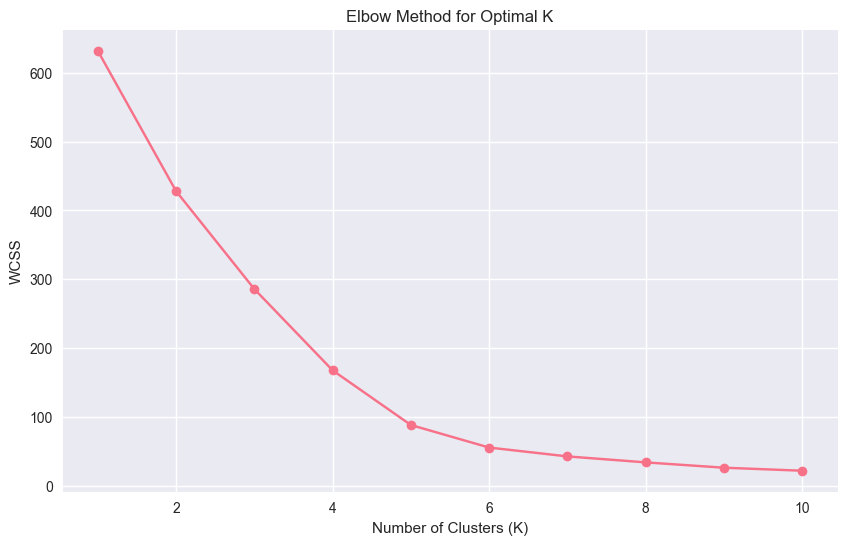


💡 Insight:

Titik siku (elbow point) menunjukkan jumlah
cluster yang optimal.

Biasanya dipilih pada titik dimana penurunan
WCSS mulai melambat.



In [6]:
print("\n📈 ELBOW METHOD")
print("="*50)

# Hitung WCSS
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(df)

    wcss.append(
        model.inertia_
    )

# Visualisasi Elbow
plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title(
    "Elbow Method for Optimal K"
)

plt.grid(True)

plt.savefig(
    '../reports/figures/8_elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("""
💡 Insight:

Titik siku (elbow point) menunjukkan jumlah
cluster yang optimal.

Biasanya dipilih pada titik dimana penurunan
WCSS mulai melambat.
""")


📊 SILHOUETTE ANALYSIS


,K,Silhouette Score
0,2,0.900828
1,3,0.887844
2,4,0.737978
3,5,0.721550
4,6,0.644284
5,7,0.661913
6,8,0.629539
7,9,0.641350
8,10,0.638719


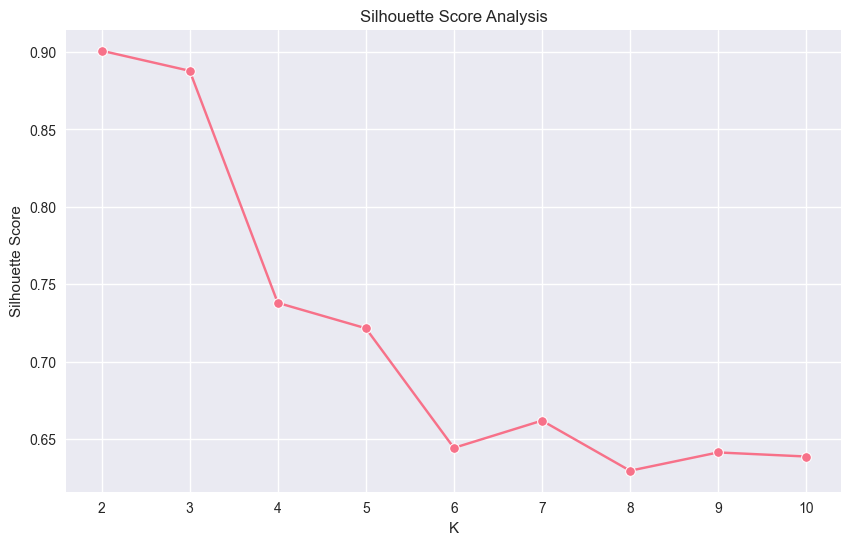

✅ Best K : 2


In [7]:
print("\n📊 SILHOUETTE ANALYSIS")
print("="*50)

# Hitung Silhouette Score
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(df)

    score = silhouette_score(
        df,
        labels
    )

    scores.append(score)

# Tabel Hasil
silhouette_df = pd.DataFrame({

    "K": range(2,11),

    "Silhouette Score": scores

})

display(
    silhouette_df
)

# Visualisasi
plt.figure(figsize=(10,6))

sns.lineplot(
    data=silhouette_df,
    x="K",
    y="Silhouette Score",
    marker="o"
)

plt.title(
    "Silhouette Score Analysis"
)

plt.grid(True)

plt.savefig(
    '../reports/figures/9_silhouette_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Best K
best_k = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(),
    "K"
]

print(f"✅ Best K : {best_k}")

In [8]:
print("\n🎯 BUILDING FINAL MODEL")
print("="*50)

# Train Model
kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(df)

# Tambahkan Label Cluster
df["Cluster"] = clusters

display(df.head())


🎯 BUILDING FINAL MODEL


,Total Events,Total Deaths,Total Affected,"Total Damage (USD, original)",Cluster
0,-0.638565,-0.088664,-0.183566,-0.243249,0
1,0.937892,-0.080750,-0.018135,-0.224128,0
2,-0.244451,-0.079608,-0.134117,-0.214568,0
3,-0.638565,-0.084478,0.056447,-0.286270,0
4,-0.244451,-0.088131,-0.191584,-0.243249,0



📌 CLUSTER DISTRIBUTION


Cluster
0    157
1      1
Name: count, dtype: int64

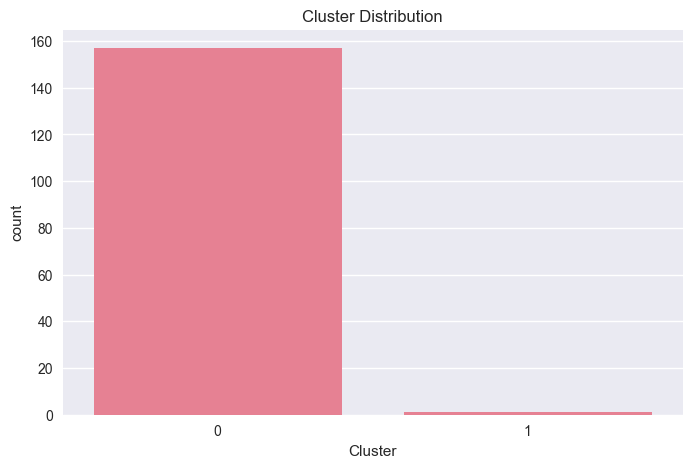

In [9]:
print("\n📌 CLUSTER DISTRIBUTION")
print("="*50)

cluster_counts = df["Cluster"].value_counts()

display(cluster_counts)

# Visualisasi
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Cluster"]
)

plt.title(
    "Cluster Distribution"
)

plt.savefig(
    '../reports/figures/10_cluster_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


📉 PCA CLUSTER VISUALIZATION


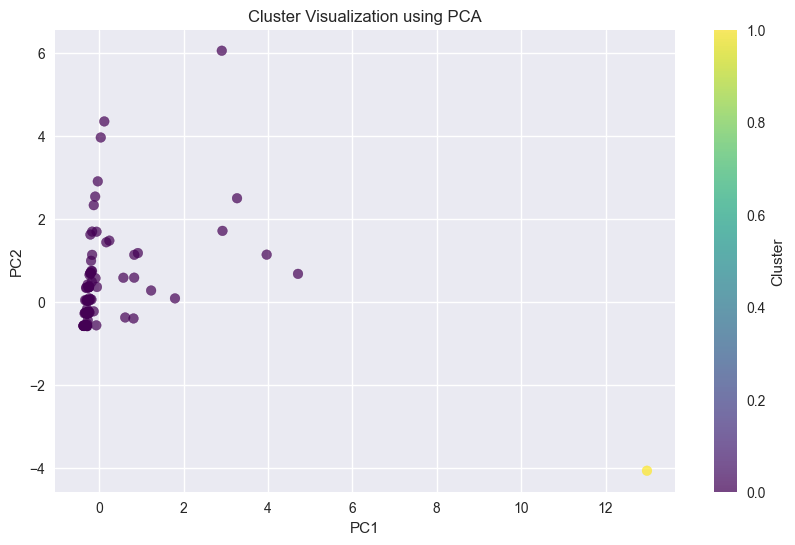

In [10]:
print("\n📉 PCA CLUSTER VISUALIZATION")
print("="*50)

pca = joblib.load(
    "../models/pca.pkl"
)

# Transform Data
X_pca = pca.transform(
    df.drop(
        columns=["Cluster"]
    )
)

# Visualisasi Scatter Plot
plt.figure(figsize=(10,6))

scatter = plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    c=df["Cluster"],

    cmap="viridis",

    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Cluster Visualization using PCA"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.savefig(
    '../reports/figures/11_cluster_visualization.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


📊 CLUSTER PROFILING


,Total Events,Total Deaths,Total Affected,"Total Damage (USD, original)"
Cluster,,,,
0,0.004067,-0.079730,-0.000961,-0.043011
1,-0.638565,12.517679,0.150952,6.752679


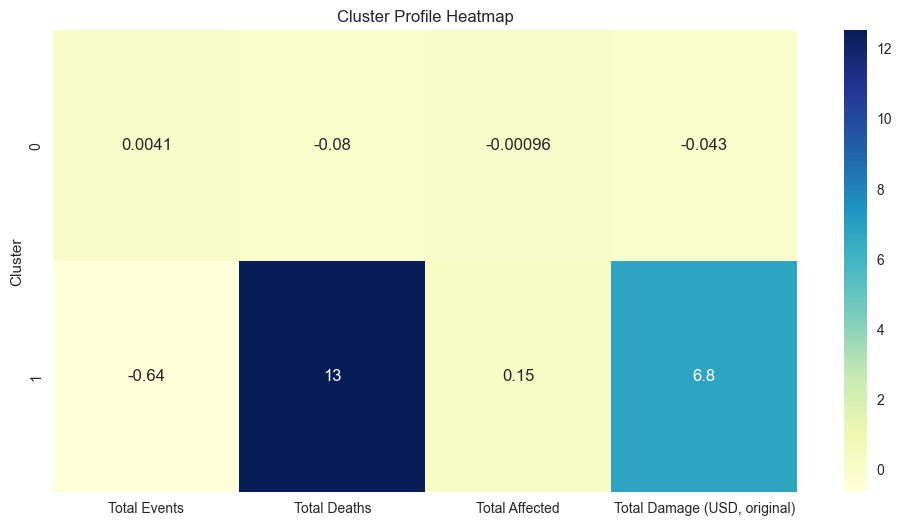


💡 Interpretasi Cluster:

Cluster dengan nilai rata-rata tertinggi
pada Total Deaths, Total Affected,
dan Total Damage dapat dianggap sebagai
cluster dengan dampak bencana tinggi.

Cluster dengan nilai lebih rendah
merepresentasikan dampak rendah.



In [11]:
print("\n📊 CLUSTER PROFILING")
print("="*50)

# Statistik Tiap Cluster
cluster_profile = df.groupby(
    "Cluster"
).mean()

display(
    cluster_profile
)

# Visualisasi Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(

    cluster_profile,

    annot=True,

    cmap="YlGnBu"

)

plt.title(
    "Cluster Profile Heatmap"
)

plt.savefig(
    '../reports/figures/12_cluster_profile.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("""
💡 Interpretasi Cluster:

Cluster dengan nilai rata-rata tertinggi
pada Total Deaths, Total Affected,
dan Total Damage dapat dianggap sebagai
cluster dengan dampak bencana tinggi.

Cluster dengan nilai lebih rendah
merepresentasikan dampak rendah.
""")

In [12]:
print("\n💾 SAVING MODEL")
print("="*50)

# Simpan Model
joblib.dump(

    kmeans,

    "../models/kmeans.pkl"

)

# Simpan Dataset Bercluster
df.to_csv(

    "../dataset/processed/disaster_clustered.csv",

    index=False

)

print("✅ kmeans.pkl saved")
print("✅ disaster_clustered.csv saved")


💾 SAVING MODEL
✅ kmeans.pkl saved
✅ disaster_clustered.csv saved
